# Using LangChain's Pandas DataFrame Agent

## Introduction

The `create_pandas_dataframe_agent` function from the `langchain_experimental.agents.agent_toolkits.pandas.base` module is a powerful tool designed to enable language models (LLMs) to interact with and analyze data stored in Pandas DataFrames. By combining the capabilities of LLMs with the flexibility of Pandas, this function allows users to perform complex data analysis tasks through natural language queries. The agent can handle a variety of operations, such as filtering, aggregation, and visualization, making it an invaluable tool for data scientists, analysts, and developers who want to streamline their workflows.

However, it is important to note that this functionality comes with significant security considerations. The agent relies on a Python REPL (Read-Eval-Print Loop) tool, which can execute arbitrary code. This capability, while powerful, introduces potential risks, such as arbitrary code execution vulnerabilities, if not used in a properly sandboxed environment. Users must explicitly opt-in to this functionality by setting the `allow_dangerous_code` parameter to `True`, acknowledging the risks and ensuring that appropriate safeguards are in place.

---

## Preparation

### Installing Required Libraries
This section installs the necessary Python libraries for working with LangChain, OpenAI embeddings, Anthropic models, and other utilities. These libraries include:
- `langchain-openai`: Provides integration with OpenAI's embedding models and APIs.
- `langchain-anthropic`: Enables integration with Anthropic's models and APIs.
- `langchain_community`: Contains community-contributed modules and tools for LangChain.
- `langchain_experimental`: Includes experimental features and utilities for LangChain.

In [1]:
!pip install -qU langchain-openai
!pip install -qU langchain-anthropic
!pip install -qU langchain_community
!pip install -qU langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.2/412.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.1/456.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.6/208.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 6.9 MB/s eta 0:00:00


### Initializing OpenAI and Anthropic Chat Models
This section demonstrates how to securely fetch API keys for OpenAI and Anthropic using Kaggle's `UserSecretsClient` and initialize their respective chat models. The `ChatOpenAI` and `ChatAnthropic` classes are used to create instances of these models, which can be used for natural language processing tasks such as text generation and conversational AI.

**Key steps:**
1. **Fetch API Keys**: The OpenAI and Anthropic API keys are securely retrieved using Kaggle's `UserSecretsClient`.
2. **Initialize Chat Models**:
   - The `ChatOpenAI` class is initialized with the `gpt-4o-mini` model and the fetched OpenAI API key.
   - The `ChatAnthropic` class is initialized with the `claude-3-5-sonnet-latest` model and the fetched Anthropic API key.

In [2]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from kaggle_secrets import UserSecretsClient

# Fetch API key securely
user_secrets = UserSecretsClient()

# Initialize LLM
model = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=user_secrets.get_secret("my-openai-api-key"))
#model = ChatAnthropic(model="claude-3-5-sonnet-latest", temperature=0, api_key=user_secrets.get_secret("my-anthropic-api-key"))

# Load the Titanic dataset
df = pd.read_csv("/kaggle/input/titanic-dataset/titanic.csv")

The provided code defines a utility function, `pretty_print_response`, designed to format and display the output of an agent's response in a clean and readable manner.

In [3]:
def pretty_print_response(question, response):
    """
    Formats and prints the agent's response in a structured and readable manner.

    This function takes a question and the agent's response, extracts the 'output' key
    from the response, and prints it with clear separators for improved readability.
    It is useful for debugging, logging, or presenting results in a user-friendly format.

    Args:
        question (str): The question or query posed to the agent.
        response (dict): The agent's response, expected to contain an 'output' key
                         with the result of the query.

    Returns:
        None: This function prints the formatted output directly to the console.
    """
    print(f"Question: {question}")
    print("\n" + "=" * 80 + "\n")
    print(response["output"])  # Extract the 'output' key for pretty printing
    print("\n" + "=" * 80 + "\n")

---

## Examples

The `create_pandas_dataframe_agent` function is a powerful tool for analyzing and interacting with Pandas DataFrames using a language model (LLM). It allows you to perform complex data analysis tasks, such as filtering, aggregation, and visualization, using natural language queries. Below are examples demonstrating the use of key parameters in `create_pandas_dataframe_agent`.

### **Example 1: Basic Usage with Default Parameters**
This example demonstrates how to create a Pandas agent with default parameters. The agent is initialized with a DataFrame and a language model (`llm`). It can answer questions about the dataset, such as column names, data types, and basic statistics.

In [4]:
import pandas as pd
from langchain_experimental.agents import create_pandas_dataframe_agent

# Load the Titanic dataset
df = pd.read_csv("/kaggle/input/titanic-dataset/titanic.csv")

# Create the agent with default parameters
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",  # Use the modern "tool-calling" agent type
    allow_dangerous_code=True,  # Allow execution of Python code (use with caution)
    verbose=True,               # Enable verbose logging for debugging
)

# Ask the agent a question
response = agent.invoke("What are the columns in the dataset and their data types?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df.dtypes'}`


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: objectThe columns in the dataset and their data types are as follows:

- **PassengerId**: int64
- **Survived**: int64
- **Pclass**: int64
- **Name**: object
- **Sex**: object
- **Age**: float64
- **SibSp**: int64
- **Parch**: int64
- **Ticket**: object
- **Fare**: float64
- **Cabin**: object
- **Embarked**: object

> Finished chain.
The columns in the dataset and their data types are as follows:

- **PassengerId**: int64
- **Survived**: int64
- **Pclass**: int64
- **Name**: object
- **Sex**: object
- **Age**: float64
- **SibSp**: int64
- **Parch**: int64
- **Ticket**: object
- **Fare**: float64
- **Cabin**: o

### **Example 2: Custom Prompt Prefix and Suffix**
This example shows how to use the `prefix` and `suffix` parameters to customize the agent's behavior. The `prefix` provides context for the agent, while the `suffix` specifies the format of the output.

In [5]:
# Create the agent with a custom prefix and suffix
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    prefix="You are a data analyst. Analyze the Titanic dataset and provide concise answers.",
    suffix="Provide the final answer in a clear and structured format.",
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent a question
response = agent.invoke("What is the average age of passengers?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\ndf = pd.read_csv('titanic.csv')\naverage_age = df['Age'].mean()\naverage_age"}`


FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'It seems that I don't have access to the Titanic dataset directly. However, you can calculate the average age of passengers using the following steps in Python:

1. Load the dataset using pandas.
2. Calculate the mean of the 'Age' column.

Here is a sample code snippet you can use:

```python
import pandas as pd

# Load the dataset
df = pd.read_csv('titanic.csv')

# Calculate the average age
average_age = df['Age'].mean()
print(average_age)
```

If you have the dataset available, you can run this code in your local environment to get the average age of the passengers. If you need further assistance, please let me know!

> Finished chain.
It seems that I don't have access to the Titanic dataset directly. However, you can calculate 

### **Example 3: Including DataFrame Head in the Prompt**
This example demonstrates how to include the first few rows of the DataFrame in the prompt using the `include_df_in_prompt` and `number_of_head_rows` parameters. This helps the agent understand the structure of the data.

In [6]:
# Create the agent with the first 5 rows included in the prompt
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    include_df_in_prompt=True,  # Include the DataFrame head in the prompt
    number_of_head_rows=5,      # Number of rows to include
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent a question
response = agent.invoke("What are the unique values in the 'Pclass' column?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df['Pclass'].unique()"}`


[3 1 2]The unique values in the 'Pclass' column are 1, 2, and 3.

> Finished chain.
The unique values in the 'Pclass' column are 1, 2, and 3.


### **Example 4: Adding Extra Tools**
This example shows how to add extra tools to the agent using the `extra_tools` parameter. These tools can extend the agent's capabilities, such as performing custom calculations or interacting with external APIs.

In [7]:
from langchain.tools import Tool

# Define a custom tool
def custom_calculation_tool(input: str) -> str:
    return f"Custom calculation result for: {input}"

# Add the custom tool to the agent
extra_tools = [
    Tool(
        name="custom_calculation",
        func=custom_calculation_tool,
        description="A tool for performing custom calculations."
    )
]

# Create the agent with extra tools
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    extra_tools=extra_tools,  # Add custom tools
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent to use the custom tool
response = agent.invoke("Use the custom_calculation tool to process 'example input'.")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `custom_calculation` with `example input`


Custom calculation result for: example inputThe custom calculation has been processed, and the result is: "Custom calculation result for: example input". If you have any specific calculations or data processing in mind, please let me know!

> Finished chain.
The custom calculation has been processed, and the result is: "Custom calculation result for: example input". If you have any specific calculations or data processing in mind, please let me know!


### **Example 5: Limiting Execution Time and Iterations**
This example demonstrates how to limit the agent's execution time and the number of iterations using the `max_execution_time` and `max_iterations` parameters. This is useful for controlling resource usage.

In [8]:
# Create the agent with execution limits
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    max_execution_time=10,  # Limit execution time to 10 seconds
    max_iterations=5,       # Limit the number of iterations to 5
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent a question
response = agent.invoke("What is the survival rate of passengers?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "survival_rate = df['Survived'].mean() * 100\nsurvival_rate"}`


38.38383838383838The survival rate of passengers is approximately 38.38%.

> Finished chain.
The survival rate of passengers is approximately 38.38%.


### **Example 6: Handling Missing Data**
This example demonstrates how to use the agent to identify and handle missing data in the DataFrame.

In [9]:
# Create the agent
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent to identify missing data
response = agent.invoke("Which columns have missing data, and how should we handle them?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'missing_data = df.isnull().sum()\nmissing_data[missing_data > 0]'}`


Age         177
Cabin       687
Embarked      2
dtype: int64The columns with missing data in the dataframe are:

1. **Age**: 177 missing values
2. **Cabin**: 687 missing values
3. **Embarked**: 2 missing values

### Handling Missing Data

1. **Age**:
   - **Imputation**: You can fill missing values with the median or mean age, as age is a numerical variable. Alternatively, you could use more advanced techniques like regression imputation or K-nearest neighbors (KNN) imputation.
   - **Categorization**: You could also create a new category for missing ages if it makes sense in the context of your analysis.

2. **Cabin**:
   - **Drop**: Given that a large number of values are missing (687 out of 891), it might be reasonable to drop this column if it doesn't provide significant value.
   - **Imputation**: If you want to keep it, you co

### **Example 7: Customizing Early Stopping**
This example shows how to customize the early stopping behavior using the `early_stopping_method` parameter. The agent will stop processing if it encounters an error or reaches a stopping condition.

In [10]:
# Create the agent with custom early stopping
agent = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    early_stopping_method="force",  # Force stop on errors
    allow_dangerous_code=True,
    verbose=True,
)

# Ask the agent a question
response = agent.invoke("What is the average fare for each passenger class?")
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df.groupby('Pclass')['Fare'].mean()"}`


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64The average fare for each passenger class is as follows:

- **Pclass 1:** $84.15
- **Pclass 2:** $20.66
- **Pclass 3:** $13.68

> Finished chain.
The average fare for each passenger class is as follows:

- **Pclass 1:** $84.15
- **Pclass 2:** $20.66
- **Pclass 3:** $13.68


---

## Best Practices

### Example 1: Using `create_pandas_dataframe_agent` for Titanic Dataset Analysis
This example demonstrates how to use the `create_pandas_dataframe_agent` to analyze the Titanic dataset. The agent is capable of performing various data analysis tasks, such as data exploration, filtering, aggregation, and visualization, using natural language queries.

#### **Step 1: Load the Dataset and Initialize the Agent**
This code block loads the Titanic dataset and initializes the `create_pandas_dataframe_agent`. The agent is configured to use a language model (`model`) and is set to allow the execution of potentially dangerous code (e.g., Python code execution). The `verbose` flag enables detailed logging of the agent's operations.

In [11]:
# Load the Titanic dataset
df = pd.read_csv("/kaggle/input/titanic-dataset/titanic.csv")

# Create the agent
agent_executor = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True
)

#### **Step 2: Perform Data Analysis with the Agent**
This code block demonstrates how to use the agent to answer various questions about the Titanic dataset. The questions range from basic exploration to complex analysis, and the agent dynamically processes the data to provide insights. The `pretty_print_response` function is used to format and print the responses in a clean and readable way.

In [12]:
# Question 1: Basic Data Exploration
response_1 = agent_executor.invoke("What are the columns in the dataset and their data types?")
pretty_print_response("1. What are the columns in the dataset and their data types?", response_1)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df.dtypes'}`


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: objectThe columns in the dataset and their data types are as follows:

- **PassengerId**: int64
- **Survived**: int64
- **Pclass**: int64
- **Name**: object
- **Sex**: object
- **Age**: float64
- **SibSp**: int64
- **Parch**: int64
- **Ticket**: object
- **Fare**: float64
- **Cabin**: object
- **Embarked**: object

> Finished chain.
Question: 1. What are the columns in the dataset and their data types?


The columns in the dataset and their data types are as follows:

- **PassengerId**: int64
- **Survived**: int64
- **Pclass**: int64
- **Name**: object
- **Sex**: object
- **Age**: float64
- **SibSp**: int64
-

In [13]:
# Question 2: Filtering Data
response_2 = agent_executor.invoke("Find all passengers who survived.")
pretty_print_response("2. Find all passengers who survived.", response_2)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "survivors = df[df['Survived'] == 1]"}`



Invoking: `python_repl_ast` with `{'query': 'survivors'}`


     PassengerId  Survived  Pclass  \
1              2         1       1   
2              3         1       3   
3              4         1       1   
8              9         1       3   
9             10         1       2   
..           ...       ...     ...   
875          876         1       3   
879          880         1       1   
880          881         1       2   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
8    Johnson, Mrs. Oscar W (Elisabeth V

In [14]:
# Question 3: Aggregation
response_3 = agent_executor.invoke("What is the average age of passengers?")
pretty_print_response("3. What is the average age of passengers?", response_3)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df['Age'].mean()"}`


29.69911764705882The average age of passengers is approximately 29.7 years.

> Finished chain.
Question: 3. What is the average age of passengers?


The average age of passengers is approximately 29.7 years.




In [15]:
# Question 4: Grouping and Aggregation
response_4 = agent_executor.invoke("What is the average fare for each passenger class?")
pretty_print_response("4. What is the average fare for each passenger class?", response_4)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df.groupby('Pclass')['Fare'].mean()"}`


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64The average fare for each passenger class is as follows:

- **Pclass 1:** $84.15
- **Pclass 2:** $20.66
- **Pclass 3:** $13.68

> Finished chain.
Question: 4. What is the average fare for each passenger class?


The average fare for each passenger class is as follows:

- **Pclass 1:** $84.15
- **Pclass 2:** $20.66
- **Pclass 3:** $13.68






> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport matplotlib.pyplot as plt\n\n# Assuming df is already defined as the DataFrame\n# Count the number of passengers in each class\nclass_counts = df['Pclass'].value_counts()\n\n# Create a bar chart\nplt.figure(figsize=(8, 5))\nclass_counts.plot(kind='bar', color='skyblue')\nplt.title('Number of Passengers in Each Class')\nplt.xlabel('Class')\nplt.ylabel('Number of Passengers')\nplt.xticks(rotation=0)\nplt.show()"}`




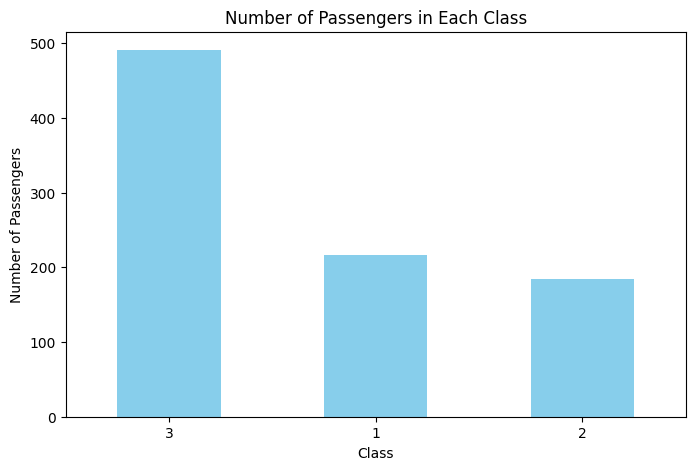

The bar chart showing the number of passengers in each class has been created successfully. If you have any further questions or need additional analysis, feel free to ask!

> Finished chain.
Question: 5. Create a bar chart showing the number of passengers in each class.


The bar chart showing the number of passengers in each class has been created successfully. If you have any further questions or need additional analysis, feel free to ask!




In [16]:
# Question 5: Visualization
response_5 = agent_executor.invoke("Create a bar chart showing the number of passengers in each class.")
pretty_print_response("5. Create a bar chart showing the number of passengers in each class.", response_5)

In [17]:
# Question 6: Conditional Analysis
response_6 = agent_executor.invoke("What is the survival rate of female passengers?")
pretty_print_response("6. What is the survival rate of female passengers?", response_6)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "female_survival_rate = df[df['Sex'] == 'female']['Survived'].mean()\nfemale_survival_rate"}`


0.7420382165605095The survival rate of female passengers is approximately 74.2%.

> Finished chain.
Question: 6. What is the survival rate of female passengers?


The survival rate of female passengers is approximately 74.2%.




In [18]:
# Question 7: Handling Missing Data
response_7 = agent_executor.invoke("Which columns have missing data, and how should we handle them?")
pretty_print_response("7. Which columns have missing data, and how should we handle them?", response_7)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'missing_data = df.isnull().sum()\nmissing_data[missing_data > 0]'}`


Age         177
Cabin       687
Embarked      2
dtype: int64The columns with missing data in the dataframe are:

1. **Age**: 177 missing values
2. **Cabin**: 687 missing values
3. **Embarked**: 2 missing values

### Handling Missing Data:

1. **Age**:
   - **Imputation**: You can fill missing values with the median or mean age, as age is a numerical variable. Alternatively, you could use more advanced techniques like regression imputation or K-nearest neighbors (KNN) imputation.
   - **Categorization**: You could also create a new category for missing ages if it makes sense in the context of your analysis.

2. **Cabin**:
   - **Drop**: Given that a large number of values are missing (687 out of 891), it might be reasonable to drop this column if it doesn't provide significant value.
   - **Imputation**: If you want to keep it, you c

In [19]:
# Question 8: Complex Query
response_8 = agent_executor.invoke("Find the names of all passengers who survived, were in first class, and are older than 30.")
pretty_print_response("8. Find the names of all passengers who survived, were in first class, and are older than 30.", response_8)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "survivors = df[(df['Survived'] == 1) & (df['Pclass'] == 1) & (df['Age'] > 30)]['Name']\nsurvivors.tolist()"}`


['Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Bonnell, Miss. Elizabeth', 'Harper, Mrs. Henry Sleeper (Myna Haxtun)', 'Icard, Miss. Amelie', 'Romaine, Mr. Charles Hallace ("Mr C Rolmane")', 'Brown, Mrs. James Joseph (Margaret Tobin)', 'Lurette, Miss. Elise', 'Blank, Mr. Henry', 'Newell, Miss. Madeleine', 'Bazzani, Miss. Albina', 'Hoyt, Mr. Frederick Maxfield', 'Harris, Mrs. Henry Birkhardt (Irene Wallach)', 'Beckwith, Mr. Richard Leonard', 'Ward, Miss. Anna', 'Graham, Mrs. William Thompson (Edith Junkins)', 'Bissette, Miss. Amelia', 'Andrews, Miss. Kornelia Theodosia', 'Baxter, Mrs. James (Helene DeLaudeniere Chaput)', 'Wick, Miss. Mary Natalie', 'Spedden, Mrs. Frederic Oakley (Margaretta Corning Stone)', 'Young, Miss. Marie Grice', '

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


The names of all passengers who survived, were in first class, and are older than 30 are:

1. Cumings, Mrs. John Bradley (Florence Briggs Thayer)
2. Futrelle, Mrs. Jacques Heath (Lily May Peel)
3. Bonnell, Miss. Elizabeth
4. Harper, Mrs. Henry Sleeper (Myna Haxtun)
5. Icard, Miss. Amelie
6. Romaine, Mr. Charles Hallace ("Mr C Rolmane")
7. Brown, Mrs. James Joseph (Margaret Tobin)
8. Lurette, Miss. Elise
9. Blank, Mr. Henry
10. Newell, Miss. Madeleine
11. Bazzani, Miss. Albina
12. Hoyt, Mr. Frederick Maxfield
13. Harris, Mrs. Henry Birkhardt (Irene Wallach)
14. Beckwith, Mr. Richard Leonard
15. Ward, Miss. Anna
16. Graham, Mrs. William Thompson (Edith Junkins)
17. Bissette, Miss. Amelia
18. Andrews, Miss. Kornelia Theodosia
19. Baxter, Mrs. James (Helene DeLaudeniere Chaput)
20. Wick, Miss. Mary Natalie
21. Spedden, Mrs. Frederic Oakley (Margaretta Corning Stone)
22. Young, Miss. Marie Grice
23. Burns, Miss. Elizabeth Margaret
24. Warren, Mrs. Frank Manley (Anna Sophia Atkinson)
25. Bid

#### **Step 3: Custom Prompt for Advanced Analysis**
This code block demonstrates how to use a custom prompt to guide the agent's behavior. The agent is initialized with a prefix that instructs it to act as a data analyst and provide concise answers. This is useful for tailoring the agent's responses to specific tasks or audiences.

In [20]:
# Question 9: Custom Prompt
agent_executor_custom = create_pandas_dataframe_agent(
    model,
    df,
    agent_type="tool-calling",
    prefix="You are a data analyst. Analyze the Titanic dataset and provide concise answers.",
    allow_dangerous_code=True,
    verbose=True
)
response_9 = agent_executor_custom.invoke("What is the distribution of passengers by gender?")
pretty_print_response("9. What is the distribution of passengers by gender?", response_9)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df['Sex'].value_counts()"}`


Sex
male      577
female    314
Name: count, dtype: int64The distribution of passengers by gender is as follows:
- Male: 577
- Female: 314

> Finished chain.
Question: 9. What is the distribution of passengers by gender?


The distribution of passengers by gender is as follows:
- Male: 577
- Female: 314




### Example 2: Using `create_pandas_dataframe_agent` for Data Analysis

This example demonstrates how to use the `create_pandas_dataframe_agent` to analyze multiple DataFrames without merging them in advance. The agent is capable of performing operations like filtering, aggregation, and conditional analysis across multiple DataFrames dynamically.

#### **Step 1: Create DataFrames**
This code block creates three DataFrames:
1. **`df_titanic`**: Contains passenger details like `PassengerId`, `Name`, `Pclass`, and `Fare`.
2. **`df_fare_category`**: Maps `Pclass` to `FareCategory` (e.g., First Class, Second Class, Economy).
3. **`df_discount`**: Contains `PassengerId` and `Discount` percentages.

In [21]:
import pandas as pd

# Create the first DataFrame: Titanic passenger data
data_titanic = {
    "PassengerId": [1, 2, 3, 4, 5],
    "Name": ["Braund, Mr. Owen Harris", "Cumings, Mrs. John Bradley", "Heikkinen, Miss. Laina", "Futrelle, Mrs. Jacques Heath", "Allen, Mr. William Henry"],
    "Pclass": [3, 1, 3, 1, 3],
    "Fare": [7.25, 71.2833, 7.925, 53.1, 8.05],
}

df_titanic = pd.DataFrame(data_titanic)

# Create the second DataFrame: Fare category data
data_fare_category = {
    "Pclass": [1, 2, 3],
    "FareCategory": ["First Class", "Second Class", "Economy"],
}

df_fare_category = pd.DataFrame(data_fare_category)

# Create the third DataFrame: Discount data
data_discount = {
    "PassengerId": [1, 2, 3, 4, 5],
    "Discount": [0.0, 5.0, 0.0, 10.0, 0.0],  # Discounts in percentage
}

df_discount = pd.DataFrame(data_discount)

#### **Step 2: Initialize the Agent**
This code block initializes the `create_pandas_dataframe_agent` with multiple DataFrames. The agent can dynamically join, filter, and analyze data across these DataFrames.

In [22]:
from langchain_experimental.agents import create_pandas_dataframe_agent

# Create the agent with multiple DataFrames
agent = create_pandas_dataframe_agent(
    model,
    [df_titanic, df_fare_category, df_discount],  # Pass multiple DataFrames as a list
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True
)

#### **Step 3: Perform Data Analysis**
This code block demonstrates how to use the agent to answer various questions about the data. The questions range from basic exploration to complex analysis, and the agent dynamically processes the DataFrames to provide insights.

In [23]:
# Question 1: Basic Data Exploration
response_1 = agent.invoke("What are the columns in each DataFrame and their data types?")
pretty_print_response("1. What are the columns in each DataFrame and their data types?", response_1)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df1.dtypes'}`


PassengerId      int64
Name            object
Pclass           int64
Fare           float64
dtype: object
Invoking: `python_repl_ast` with `{'query': 'df2.dtypes'}`


Pclass           int64
FareCategory    object
dtype: object
Invoking: `python_repl_ast` with `{'query': 'df3.dtypes'}`


PassengerId      int64
Discount       float64
dtype: objectHere are the columns and their data types for each DataFrame:

### DataFrame 1 (df1)
- **PassengerId**: int64
- **Name**: object
- **Pclass**: int64
- **Fare**: float64

### DataFrame 2 (df2)
- **Pclass**: int64
- **FareCategory**: object

### DataFrame 3 (df3)
- **PassengerId**: int64
- **Discount**: float64

> Finished chain.
Question: 1. What are the columns in each DataFrame and their data types?


Here are the columns and their data types for each DataFrame:

### DataFrame 1 (df1)
- **PassengerId**: int64
- **Name**: object
- **Pclass**: in

In [24]:
# Question 2: Filtering Data
response_2 = agent.invoke("Find all passengers in First Class by joining df_titanic and df_fare_category.")
pretty_print_response("2. Find all passengers in First Class by joining df_titanic and df_fare_category.", response_2)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\n# Sample data for df1 (df_titanic)\ndata1 = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath', 'Allen, Mr. William Henry'],\n    'Pclass': [3, 1, 3, 1, 3],\n    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]\n}\n\ndf_titanic = pd.DataFrame(data1)\n\n# Sample data for df2 (df_fare_category)\ndata2 = {\n    'Pclass': [1, 2, 3],\n    'FareCategory': ['First Class', 'Second Class', 'Economy']\n}\n\ndf_fare_category = pd.DataFrame(data2)\n\n# Performing the join to find all passengers in First Class\nresult = pd.merge(df_titanic, df_fare_category, on='Pclass')\nfirst_class_passengers = result[result['FareCategory'] == 'First Class']\nfirst_class_passengers"}`


   PassengerId                          Name  Pclass     Fare FareCategory
1            2    Cumings, Mrs. John B

In [25]:
# Question 3: Aggregation
response_3 = agent.invoke("What is the average fare for each fare category? Use df_titanic and df_fare_category.")
pretty_print_response("3. What is the average fare for each fare category? Use df_titanic and df_fare_category.", response_3)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\n# Sample data for df1 (df_titanic)\ndata_titanic = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath', 'Allen, Mr. William Henry'],\n    'Pclass': [3, 1, 3, 1, 3],\n    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]\n}\n\ndf_titanic = pd.DataFrame(data_titanic)\n\n# Sample data for df2 (df_fare_category)\ndata_fare_category = {\n    'Pclass': [1, 2, 3],\n    'FareCategory': ['First Class', 'Second Class', 'Economy']\n}\n\ndf_fare_category = pd.DataFrame(data_fare_category)\n\n# Merging the dataframes on Pclass\nmerged_df = pd.merge(df_titanic, df_fare_category, on='Pclass')\n\n# Calculating the average fare for each fare category\naverage_fare = merged_df.groupby('FareCategory')['Fare'].mean().reset_index()\naverage_fare"}`


  FareCategory       Fare
0      Economy   

In [26]:
# Question 4: Conditional Analysis
response_4 = agent.invoke("What is the total fare for passengers who received a discount? Use df_titanic and df_discount.")
pretty_print_response("4. What is the total fare for passengers who received a discount? Use df_titanic and df_discount.", response_4)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\n# Sample data for df_titanic\ndata_titanic = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath', 'Allen, Mr. William Henry'],\n    'Pclass': [3, 1, 3, 1, 3],\n    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]\n}\n\ndf_titanic = pd.DataFrame(data_titanic)\n\n# Sample data for df_discount\ndata_discount = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Discount': [0, 5, 0, 10, 0]\n}\n\ndf_discount = pd.DataFrame(data_discount)"}`



Invoking: `python_repl_ast` with `{'query': "# Merging the two dataframes on 'PassengerId'\nmerged_df = pd.merge(df_titanic, df_discount, on='PassengerId')\n\n# Filtering passengers who received a discount\ndiscounted_passengers = merged_df[merged_df['Discount'] > 0]\n\n# Calculating the total fare for these passengers\ntotal_fare_discounted = 

In [27]:
# Question 5: Complex Query
response_5 = agent.invoke("Find the names of passengers who paid more than $50 in total fare. Use all DataFrames.")
pretty_print_response("5. Find the names of passengers who paid more than $50 in total fare. Use all DataFrames.", response_5)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\n# Sample data for df1\ndata1 = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath', 'Allen, Mr. William Henry'],\n    'Pclass': [3, 1, 3, 1, 3],\n    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]\n}\ndf1 = pd.DataFrame(data1)\n\n# Sample data for df2\ndata2 = {\n    'Pclass': [1, 2, 3],\n    'FareCategory': ['First Class', 'Second Class', 'Economy']\n}\ndf2 = pd.DataFrame(data2)\n\n# Sample data for df3\ndata3 = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Discount': [0, 5, 0, 10, 0]\n}\ndf3 = pd.DataFrame(data3)\n\n# Merging df1 and df3 to get the total fare after discount\nmerged_df = pd.merge(df1, df3, on='PassengerId')\nmerged_df['TotalFare'] = merged_df['Fare'] - merged_df['Discount']\n\n# Filtering passengers who paid more than $50\nresult = merged_df[merged_df['

In [28]:
# Question 6: Handling Missing Data
response_6 = agent.invoke("Are there any missing values in df_titanic?")
pretty_print_response("6. Are there any missing values in df_titanic?", response_6)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df1.isnull().sum()'}`


PassengerId    0
Name           0
Pclass         0
Fare           0
dtype: int64
Invoking: `python_repl_ast` with `{'query': 'df2.isnull().sum()'}`


Pclass          0
FareCategory    0
dtype: int64
Invoking: `python_repl_ast` with `{'query': 'df3.isnull().sum()'}`


PassengerId    0
Discount       0
dtype: int64There are no missing values in any of the dataframes:

- **df1**: No missing values in `PassengerId`, `Name`, `Pclass`, or `Fare`.
- **df2**: No missing values in `Pclass` or `FareCategory`.
- **df3**: No missing values in `PassengerId` or `Discount`.

> Finished chain.
Question: 6. Are there any missing values in df_titanic?


There are no missing values in any of the dataframes:

- **df1**: No missing values in `PassengerId`, `Name`, `Pclass`, or `Fare`.
- **df2**: No missing values in `Pclass` or `FareCategory`.
- **df3**: No missing values in `PassengerId` or `Disco

In [29]:
# Question 7: Custom Prompt
response_7 = agent.invoke("You are a data analyst. Analyze the DataFrames and provide insights about fare distribution.")
pretty_print_response("7. Analyze the DataFrames and provide insights about fare distribution.", response_7)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n\n# Sample data for df1\ndata1 = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath', 'Allen, Mr. William Henry'],\n    'Pclass': [3, 1, 3, 1, 3],\n    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]\n}\n\ndf1 = pd.DataFrame(data1)\n\n# Sample data for df2\ndata2 = {\n    'Pclass': [1, 2, 3],\n    'FareCategory': ['First Class', 'Second Class', 'Economy']\n}\n\ndf2 = pd.DataFrame(data2)\n\n# Sample data for df3\ndata3 = {\n    'PassengerId': [1, 2, 3, 4, 5],\n    'Discount': [0, 5, 0, 10, 0]\n}\n\ndf3 = pd.DataFrame(data3)\n\n# Analyzing fare distribution\nfare_distribution = df1['Fare'].describe()\nfare_distribution"}`


count     5.000000
mean     29.521660
std      30.510029
min       7.250000
25%       7.925000
50%       8.050000
75%      53.100000
max      71.283300
N

---

## Conclusion
The `create_pandas_dataframe_agent` function bridges the gap between natural language processing and data analysis, enabling users to interact with Pandas DataFrames in an intuitive and efficient manner. By leveraging the strengths of LLMs, this tool simplifies complex data tasks and makes them accessible to a broader audience. However, the power of this functionality comes with a responsibility to use it securely. Users must ensure that they operate in a safe, sandboxed environment and understand the risks associated with executing arbitrary code. When used responsibly, this tool can significantly enhance productivity and unlock new possibilities for data-driven decision-making.